IS 362 Final Project
By: Patrick Diaz

College Majors and Earning

This project is going to be using a dataset from FiveThirtyEight about College Majors.

My motivation for this project was because this is my last semester and I graduate, so I was intrigued by what I and the rest of the graduating class could possibly expect, job wise after we graduate. I think some of the importing things to look at would be median salary for the majors, unemployment rates with some of the majors. Everyone expects to have an amazing job that pays well after they graduate because they got a major in a specific field but that may be the case. I think what a lot of people dont realize is that yes you can make a lot of money with some majors but it may not be smart to expect that huge salarly immediately.

First we will need to import the needed libraries

In [1]:
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt

Next we will need to load the dataset. I will be pulling this directly from the FiveThirtyEight GitHub repository so no download is needed.

In [2]:
url = 'https://raw.githubusercontent.com/fivethirtyeight/data/master/college-majors/recent-grads.csv'


majors = pd.read_csv(url)

majors.head()

,Rank,Major_code,Major,Total,Men,Women,Major_category,ShareWomen,Sample_size,Employed,...,Part_time,Full_time_year_round,Unemployed,Unemployment_rate,Median,P25th,P75th,College_jobs,Non_college_jobs,Low_wage_jobs
0,1,2419,PETROLEUM ENGINEERING,2339.0,2057.0,282.0,Engineering,0.120564,36,1976,...,270,1207,37,0.018381,110000,95000,125000,1534,364,193
1,2,2416,MINING AND MINERAL ENGINEERING,756.0,679.0,77.0,Engineering,0.101852,7,640,...,170,388,85,0.117241,75000,55000,90000,350,257,50
2,3,2415,METALLURGICAL ENGINEERING,856.0,725.0,131.0,Engineering,0.153037,3,648,...,133,340,16,0.024096,73000,50000,105000,456,176,0
3,4,2417,NAVAL ARCHITECTURE AND MARINE ENGINEERING,1258.0,1123.0,135.0,Engineering,0.107313,16,758,...,150,692,40,0.050125,70000,43000,80000,529,102,0
4,5,2405,CHEMICAL ENGINEERING,32260.0,21239.0,11021.0,Engineering,0.341631,289,25694,...,5180,16697,1672,0.061098,65000,50000,75000,18314,4440,972


We should examine the dataset a little so I will view the information and check for any missing values

In [8]:
majors.info()
majors.isnull().sum()
majors = majors.dropna(subset=['Median'])

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 173 entries, 0 to 172
Data columns (total 21 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Rank                  173 non-null    int64  
 1   Major_code            173 non-null    int64  
 2   Major                 173 non-null    object 
 3   Total                 172 non-null    float64
 4   Men                   172 non-null    float64
 5   Women                 172 non-null    float64
 6   Major_category        173 non-null    object 
 7   ShareWomen            172 non-null    float64
 8   Sample_size           173 non-null    int64  
 9   Employed              173 non-null    int64  
 10  Full_time             173 non-null    int64  
 11  Part_time             173 non-null    int64  
 12  Full_time_year_round  173 non-null    int64  
 13  Unemployed            173 non-null    int64  
 14  Unemployment_rate     173 non-null    float64
 15  Median                1

We need to create the SQLite Database now to store the relational tables

In [9]:
conn = sqlite3.connect('college_majors.db')

Now that we have the SQLite database set up we can create the relational tables for different columns. We'll do a table for Major, Earnings, and Employment

In [ ]:
majors[['Major_code', 'Major', 'Major_category']].to_sql(
    'majors_table',
    conn,
    if_exists='replace',
    index=False
)

173

In [ ]:
majors[['Major_code', 'Median', 'P25th', 'P75th']].to_sql(
    'earnings_table',
    conn,
    if_exists='replace',
    index=False
)

173

In [ ]:
majors[['Major_code', 'Employed', 'Unemployed', 'Unemployment_rate']].to_sql(
    'employment_table',
    conn,
    if_exists='replace',
    index=False
)

173

Now that we completed the tables we will view and verify them. We will need to use SQL queries to confirm

In [ ]:
pd.read_sql('SELECT * FROM majors_table LIMIT 5', conn)

,Major_code,Major,Major_category
0,2419,PETROLEUM ENGINEERING,Engineering
1,2416,MINING AND MINERAL ENGINEERING,Engineering
2,2415,METALLURGICAL ENGINEERING,Engineering
3,2417,NAVAL ARCHITECTURE AND MARINE ENGINEERING,Engineering
4,2405,CHEMICAL ENGINEERING,Engineering


In [ ]:
pd.read_sql('SELECT * FROM earnings_table LIMIT 5', conn)

,Major_code,Median,P25th,P75th
0,2419,110000,95000,125000
1,2416,75000,55000,90000
2,2415,73000,50000,105000
3,2417,70000,43000,80000
4,2405,65000,50000,75000


In [ ]:
pd.read_sql('SELECT * FROM employment_table LIMIT 5', conn)

,Major_code,Employed,Unemployed,Unemployment_rate
0,2419,1976,37,0.018381
1,2416,640,85,0.117241
2,2415,648,16,0.024096
3,2417,758,40,0.050125
4,2405,25694,1672,0.061098


Since we have now verified and have the tables set up with cleaned data, we can start analying and creating tables for a visual

The first analysis will be of the top 10 highest paying median salaries

In [16]:
highest_salary = majors[['Major', 'Median']]

highest_salary = highest_salary.sort_values(
    by='Median',
    ascending=False
)

highest_salary.head(10)

,Major,Median
0,PETROLEUM ENGINEERING,110000
1,MINING AND MINERAL ENGINEERING,75000
2,METALLURGICAL ENGINEERING,73000
3,NAVAL ARCHITECTURE AND MARINE ENGINEERING,70000
4,CHEMICAL ENGINEERING,65000
5,NUCLEAR ENGINEERING,65000
6,ACTUARIAL SCIENCE,62000
7,ASTRONOMY AND ASTROPHYSICS,62000
8,MECHANICAL ENGINEERING,60000
9,ELECTRICAL ENGINEERING,60000


Lets do a visual for this analysis with a bar chart

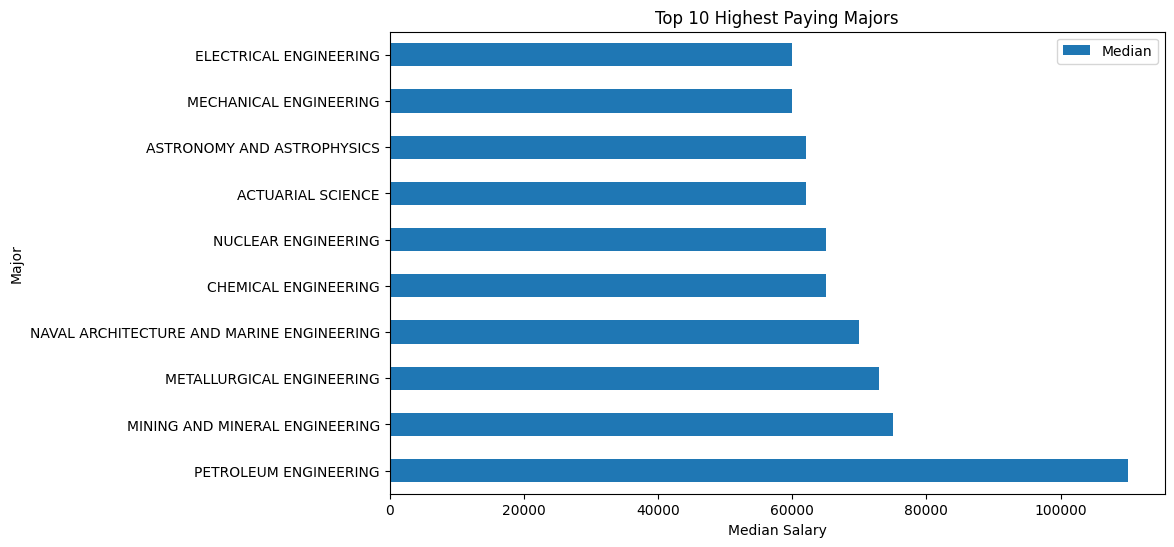

In [17]:
highest_salary.head(10).plot(
    kind='barh',
    x='Major',
    y='Median',
    figsize=(10,6)
)

plt.title('Top 10 Highest Paying Majors')
plt.xlabel('Median Salary')
plt.ylabel('Major')

plt.show()

The next analysis will be of unemployment rate by major

In [24]:
unemployment = majors.groupby(
    'Major_category'
)['Unemployment_rate'].mean()

unemployment.sort_values(ascending=False)

Major_category
Social Science                         0.095729
Law & Public Policy                    0.090805
Arts                                   0.090173
Computers & Mathematics                0.084256
Humanities & Liberal Arts              0.081008
Communications & Journalism            0.075538
Psychology & Social Work               0.072065
Business                               0.071064
Interdisciplinary                      0.070861
Health                                 0.065920
Engineering                            0.063334
Biology & Life Science                 0.060918
Agriculture & Natural Resources        0.056328
Education                              0.051702
Industrial Arts & Consumer Services    0.048071
Physical Sciences                      0.046511
Name: Unemployment_rate, dtype: float64

Let represent this with a bar chart as well

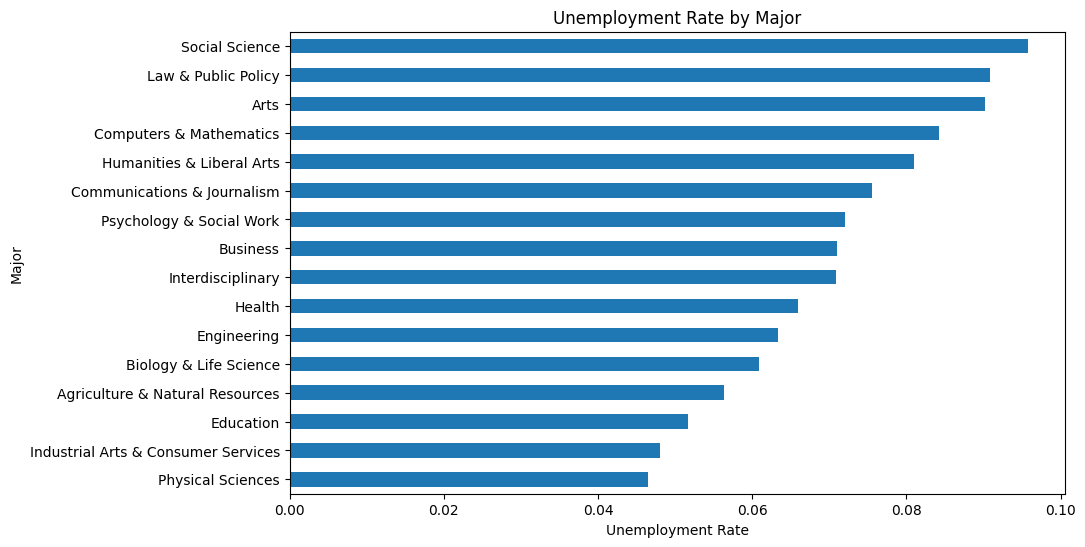

In [22]:
# Bar chart
unemployment.sort_values().plot(
    kind='barh',
    figsize=(10,6)
)

plt.title('Unemployment Rate by Major')
plt.xlabel('Unemployment Rate')
plt.ylabel('Major')

plt.show()

I think it would be interesting to see what the mojority of median salaries is, so we can show this by creating a histogram

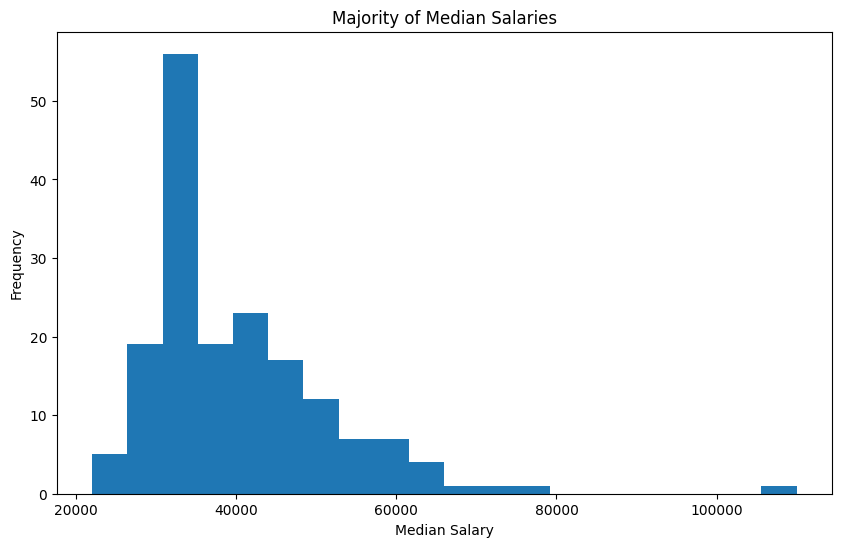

In [26]:
majors['Median'].plot(
    kind='hist',
    bins=20,
    figsize=(10,6)
)

plt.title('Majority of Median Salaries')
plt.xlabel('Median Salary')

plt.show()

We have done pandas analysis, so I will use an SQL query to display the salary information

In [28]:
query = '''
SELECT majors_table.Major,
       earnings_table.Median
FROM majors_table
JOIN earnings_table
ON majors_table.Major_code = earnings_table.Major_code
ORDER BY earnings_table.Median DESC
LIMIT 10
'''

pd.read_sql(query, conn)

,Major,Median
0,PETROLEUM ENGINEERING,110000
1,MINING AND MINERAL ENGINEERING,75000
2,METALLURGICAL ENGINEERING,73000
3,NAVAL ARCHITECTURE AND MARINE ENGINEERING,70000
4,CHEMICAL ENGINEERING,65000
5,NUCLEAR ENGINEERING,65000
6,ACTUARIAL SCIENCE,62000
7,ASTRONOMY AND ASTROPHYSICS,62000
8,MECHANICAL ENGINEERING,60000
9,ELECTRICAL ENGINEERING,60000


This produces the same thing as the highest_salary code but with a SQL query instead

Based on the analysis the conclusions I have reached are:

The engineering majors had some of the highest salaries
Unemployment rates differed between the majors
The salary ranges varied but a chunk are between 25-55 thousand